## Build A CNN - project to analysis the IAmge and Predict the value

In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device Used : " , device)

Device Used :  cpu


In [3]:
# Transform and Train the data
transform = transforms.ToTensor()

train_data = MNIST(
    root = "data",
    train = True,
    download = True,
    transform = transform
)

100.0%
100.0%
100.0%
100.0%


In [4]:
#test the data
test_data = MNIST(
    root = "data",
    train = False,
    download = True,
    transform = transform
)

In [5]:
# train loader and test loader 
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data , batch_size = 64 , shuffle = False)

In [6]:
#creating a class & Function of this model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1 , 8 , kernel_size = 3 , padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8 , 16 , kernel_size = 3 , padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2) ,
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 7 * 7 , 64),
            nn.ReLU(),
            nn.Linear(64 , 10),
        )

    def forward(self , x):
        x = self.features(x)
        x = x.view(x.size(0) , -1)
        x = self.classifier(x)
        return x


In [7]:
#Assining The vale on my Model
model = SimpleCNN().to(device)

loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

In [8]:
#Training the epoch at 5
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = loss_fun(output , labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss : {total_loss:.2f}")

Epoch 1/5 | Loss : 352.77
Epoch 2/5 | Loss : 93.61
Epoch 3/5 | Loss : 65.17
Epoch 4/5 | Loss : 53.96
Epoch 5/5 | Loss : 44.10


In [9]:
# Testing The Model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images , labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)
        prediction = output.argmax(dim = 1)

        correct += (prediction == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy : " , accuracy)

Test Accuracy :  98.34


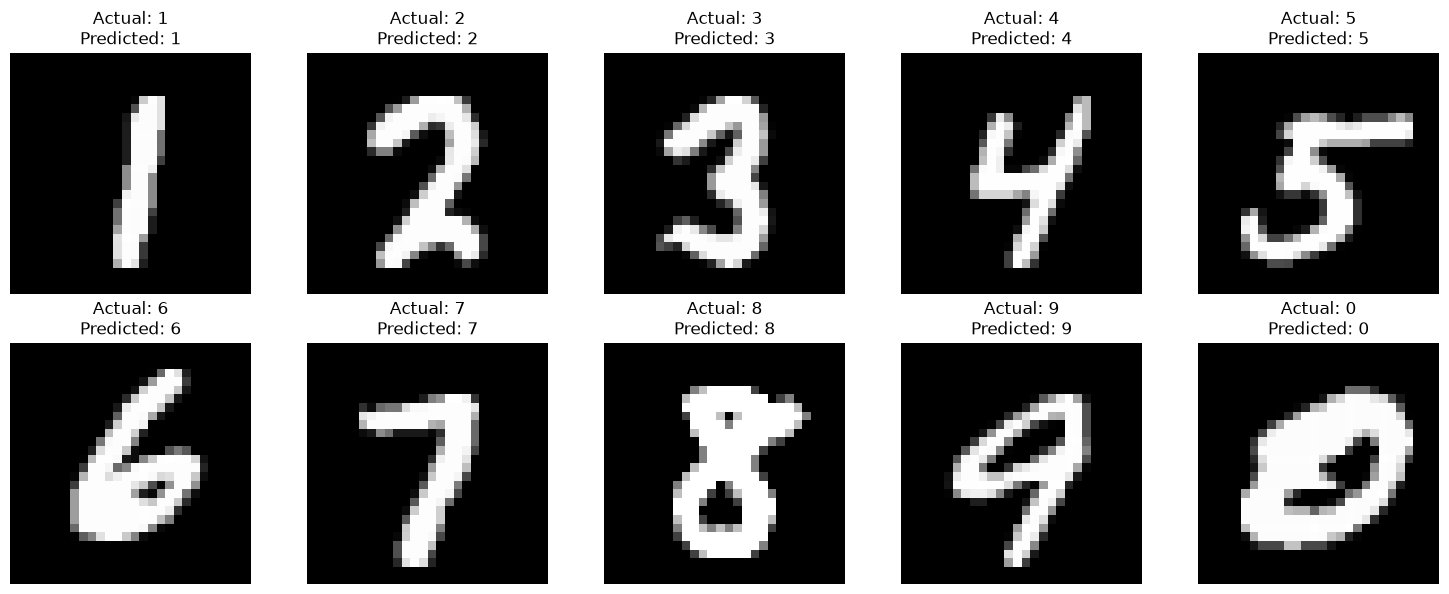

In [13]:
# Visualation
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {prediction[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
#import the model
import os

os.makedirs("models", exist_ok=True)

torch.save(model, "models/SimpleCNN.pth")

print("Model Saved Successfully")

Model Saved Successfully
